# 03 — Modeling
## MIMIC-IV ICU Length-of-Stay Project

Input: `data/processed/model_ready.csv` (output of `02_feature_engineering.ipynb`).
Trains and compares three baseline classifiers — Logistic Regression, Random
Forest, XGBoost — for the binary `prolonged_stay_label` target, using a
stratified train/test split and 5-fold stratified cross-validation. The best
model, its preprocessing pipeline, and its feature names are saved under
`models/`. SHAP explainability is explicitly **out of scope** for this
notebook — it is the next project stage (see `reports/modeling_summary.md`).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
)

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "model_ready.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Same validated palette as 01_EDA.ipynb, for a consistent report look.
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
MODEL_COLORS = {"Logistic Regression": BLUE, "Random Forest": AQUA, "XGBoost": ORANGE}
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_SECONDARY, "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "grid.color": GRIDLINE, "grid.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 100, "savefig.dpi": 200,
})

N_FIGURES_SAVED = []
def save_fig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    N_FIGURES_SAVED.append(path.name)
    print(f"Saved figure: reports/figures/{name}.png")
    plt.show()
    plt.close(fig)

df = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH.name} -> shape {df.shape}")

NUMERIC_COLS = ["age_at_admission", "first_creatinine", "first_wbc", "first_hemoglobin", "medication_count"]
X = df.drop(columns=["stay_id", "prolonged_stay_label"])
y = df["prolonged_stay_label"]
FEATURE_NAMES = X.columns.tolist()
print(f"X shape: {X.shape}, {len(FEATURE_NAMES)} features")

Loaded model_ready.csv -> shape (117, 23)
X shape: (117, 21), 21 features


## Part 2 — Train/Test Split

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, positive rate = {y_train.mean():.3f} ({y_train.sum()}/{len(y_train)})")
print(f"Test:  {X_test.shape}, positive rate = {y_test.mean():.3f} ({y_test.sum()}/{len(y_test)})")
print(f"Full dataset positive rate: {y.mean():.3f}")

Train: (93, 21), positive rate = 0.269 (25/93)
Test:  (24, 21), positive rate = 0.250 (6/24)
Full dataset positive rate: 0.265


**Why a stratified split.** With only 117 stays and a moderate 26.5%
positive rate (`reports/EDA_summary.md` §2), a plain random 80/20 split
could easily land a test set with very few positive cases by chance — with
only ~23 test rows, drawing e.g. 2 or 3 positives instead of ~6 is entirely
plausible under random sampling, and precision/recall/F1 become unstable or
even undefined (division by zero) at that scale. Stratifying on the target
forces both the train and test sets to preserve the overall ~26.5% positive
rate (confirmed above: 26.9% train, 25.0% test), which is what makes the
held-out test metrics computed later actually comparable to the
cross-validation metrics computed on the training set.

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for i, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"fold {i+1}: train={len(tr_idx)} (pos={y_train.iloc[tr_idx].sum()}), "
          f"val={len(va_idx)} (pos={y_train.iloc[va_idx].sum()})")

fold 1: train=74 (pos=20), val=19 (pos=5)
fold 2: train=74 (pos=20), val=19 (pos=5)
fold 3: train=74 (pos=20), val=19 (pos=5)
fold 4: train=75 (pos=20), val=18 (pos=5)
fold 5: train=75 (pos=20), val=18 (pos=5)


## Part 3 — Modeling: Three Baseline Classifiers

Hyperparameters below are fixed, reasonable defaults — **no grid search or
extensive tuning was performed**, deliberately: with 93 training rows,
tuning against a 5-fold CV score would itself risk overfitting to CV noise
rather than finding a genuinely better model. Each choice is tied to a
finding already established earlier in the project:

- **Logistic Regression** — `class_weight="balanced"` (compensates for the
  26.5% positive rate found in the EDA), `C=1.0` (default L2 regularization
  strength), features scaled via a `ColumnTransformer` that standardizes
  only `NUMERIC_COLS`, fit on the training fold only (never on test data).
- **Random Forest** — `n_estimators=300`, `max_depth=5`,
  `min_samples_leaf=3`, `class_weight="balanced"`. Depth and leaf-size caps
  are set conservatively given the small training set (93 rows), to limit
  overfitting.
- **XGBoost** — `n_estimators=300`, `max_depth=3` (shallow, same
  small-n reasoning), `learning_rate=0.05`, `subsample=0.8`,
  `colsample_bytree=0.8`, `scale_pos_weight` computed from the training
  fold's class ratio (the boosting-model equivalent of `class_weight`).

All three are wrapped as `scikit-learn` `Pipeline` objects — even the two
tree models, which don't need scaling — so all three share one uniform
`.fit()` / `.predict()` interface and can be saved/loaded identically in
Part 6.

In [4]:
preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), NUMERIC_COLS)],
    remainder="passthrough",
)
passthrough = ColumnTransformer(transformers=[], remainder="passthrough")

pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos

pipelines = {
    "Logistic Regression": Pipeline([
        ("pre", preprocessor),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0, random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("pre", passthrough),
        ("clf", RandomForestClassifier(
            n_estimators=300, max_depth=5, min_samples_leaf=3,
            class_weight="balanced", random_state=42)),
    ]),
    "XGBoost": Pipeline([
        ("pre", passthrough),
        ("clf", XGBClassifier(
            n_estimators=300, max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42)),
    ]),
}
print(f"scale_pos_weight (train set neg/pos ratio) = {scale_pos_weight:.3f}")
print("Pipelines defined:", list(pipelines.keys()))

scale_pos_weight (train set neg/pos ratio) = 2.720
Pipelines defined: ['Logistic Regression', 'Random Forest', 'XGBoost']


In [5]:
cv_results = {}
for name, pipe in pipelines.items():
    cv = cross_validate(
        pipe, X_train, y_train, cv=skf,
        scoring=["roc_auc", "f1", "precision", "recall"],
    )
    cv_results[name] = cv
    print(f"--- {name}: 5-fold Stratified CV (on training set) ---")
    for metric in ["roc_auc", "f1", "precision", "recall"]:
        scores = cv[f"test_{metric}"]
        print(f"  {metric:<10s} mean={scores.mean():.3f}  std={scores.std():.3f}  folds={np.round(scores,3)}")

--- Logistic Regression: 5-fold Stratified CV (on training set) ---
  roc_auc    mean=0.441  std=0.141  folds=[0.5   0.4   0.257 0.677 0.369]
  f1         mean=0.326  std=0.180  folds=[0.308 0.308 0.167 0.667 0.182]
  precision  mean=0.276  std=0.154  folds=[0.25  0.25  0.143 0.571 0.167]
  recall     mean=0.400  std=0.219  folds=[0.4 0.4 0.2 0.8 0.2]


--- Random Forest: 5-fold Stratified CV (on training set) ---
  roc_auc    mean=0.537  std=0.083  folds=[0.586 0.514 0.414 0.662 0.508]
  f1         mean=0.337  std=0.137  folds=[0.5   0.2   0.2   0.5   0.286]
  precision  mean=0.447  std=0.210  folds=[0.667 0.2   0.2   0.667 0.5  ]
  recall     mean=0.280  std=0.098  folds=[0.4 0.2 0.2 0.4 0.2]


--- XGBoost: 5-fold Stratified CV (on training set) ---
  roc_auc    mean=0.533  std=0.082  folds=[0.643 0.5   0.4   0.538 0.585]
  f1         mean=0.272  std=0.076  folds=[0.222 0.182 0.308 0.4   0.25 ]
  precision  mean=0.280  std=0.080  folds=[0.25  0.167 0.25  0.4   0.333]
  recall     mean=0.280  std=0.098  folds=[0.2 0.2 0.4 0.4 0.2]


## Part 4 — Evaluation on the Held-Out Test Set

In [6]:
test_results = {}
fitted_pipelines = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)

    test_results[name] = {
        "test_roc_auc": roc_auc_score(y_test, proba),
        "test_precision": precision_score(y_test, pred, zero_division=0),
        "test_recall": recall_score(y_test, pred, zero_division=0),
        "test_f1": f1_score(y_test, pred, zero_division=0),
        "cv_roc_auc_mean": cv_results[name]["test_roc_auc"].mean(),
        "cv_roc_auc_std": cv_results[name]["test_roc_auc"].std(),
        "cv_f1_mean": cv_results[name]["test_f1"].mean(),
        "cv_f1_std": cv_results[name]["test_f1"].std(),
        "proba": proba,
        "pred": pred,
    }

    print(f"\n=== {name} — Test Set Evaluation ===")
    print(f"ROC-AUC:   {test_results[name]['test_roc_auc']:.3f}")
    print(f"Precision: {test_results[name]['test_precision']:.3f}")
    print(f"Recall:    {test_results[name]['test_recall']:.3f}")
    print(f"F1-score:  {test_results[name]['test_f1']:.3f}")
    print("Confusion matrix ([[TN, FP], [FN, TP]]):")
    print(confusion_matrix(y_test, pred))
    print("\nClassification report:")
    print(classification_report(y_test, pred, zero_division=0))


=== Logistic Regression — Test Set Evaluation ===
ROC-AUC:   0.593
Precision: 0.333
Recall:    0.667
F1-score:  0.444
Confusion matrix ([[TN, FP], [FN, TP]]):
[[10  8]
 [ 2  4]]

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.56      0.67        18
           1       0.33      0.67      0.44         6

    accuracy                           0.58        24
   macro avg       0.58      0.61      0.56        24
weighted avg       0.71      0.58      0.61        24




=== Random Forest — Test Set Evaluation ===
ROC-AUC:   0.593
Precision: 0.333
Recall:    0.333
F1-score:  0.333
Confusion matrix ([[TN, FP], [FN, TP]]):
[[14  4]
 [ 4  2]]

Classification report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78        18
           1       0.33      0.33      0.33         6

    accuracy                           0.67        24
   macro avg       0.56      0.56      0.56        24
weighted avg       0.67      0.67      0.67        24




=== XGBoost — Test Set Evaluation ===
ROC-AUC:   0.481
Precision: 0.222
Recall:    0.333
F1-score:  0.267
Confusion matrix ([[TN, FP], [FN, TP]]):
[[11  7]
 [ 4  2]]

Classification report:
              precision    recall  f1-score   support

           0       0.73      0.61      0.67        18
           1       0.22      0.33      0.27         6

    accuracy                           0.54        24
   macro avg       0.48      0.47      0.47        24
weighted avg       0.61      0.54      0.57        24



Saved figure: reports/figures/model_roc_curves.png


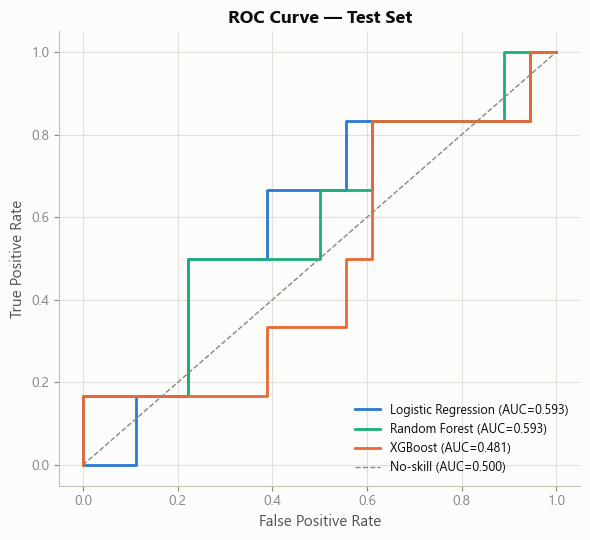

In [7]:
fig, ax = plt.subplots(figsize=(6, 5.5))
for name, res in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    ax.plot(fpr, tpr, color=MODEL_COLORS[name], linewidth=2,
            label=f"{name} (AUC={res['test_roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], color=INK_MUTED, linestyle="--", linewidth=1, label="No-skill (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set")
ax.legend(fontsize=9, frameon=False, loc="lower right")
save_fig(fig, "model_roc_curves")

Saved figure: reports/figures/model_precision_recall_curves.png


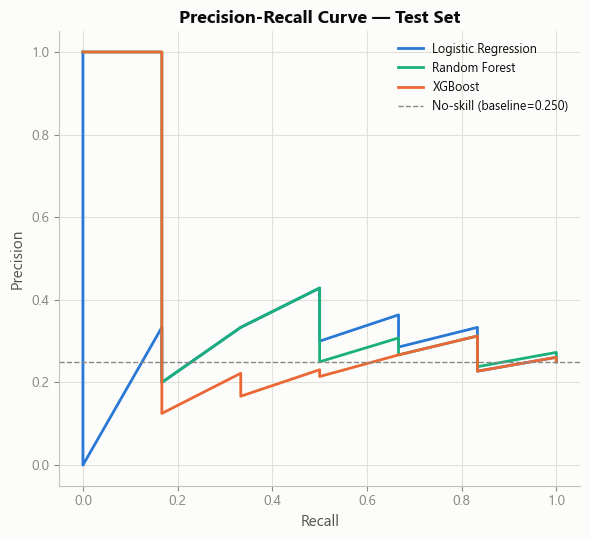

In [8]:
baseline_rate = y_test.mean()
fig, ax = plt.subplots(figsize=(6, 5.5))
for name, res in test_results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["proba"])
    ax.plot(rec, prec, color=MODEL_COLORS[name], linewidth=2, label=name)
ax.axhline(baseline_rate, color=INK_MUTED, linestyle="--", linewidth=1,
           label=f"No-skill (baseline={baseline_rate:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Test Set")
ax.legend(fontsize=9, frameon=False, loc="upper right")
save_fig(fig, "model_precision_recall_curves")

Saved figure: reports/figures/model_confusion_matrices.png


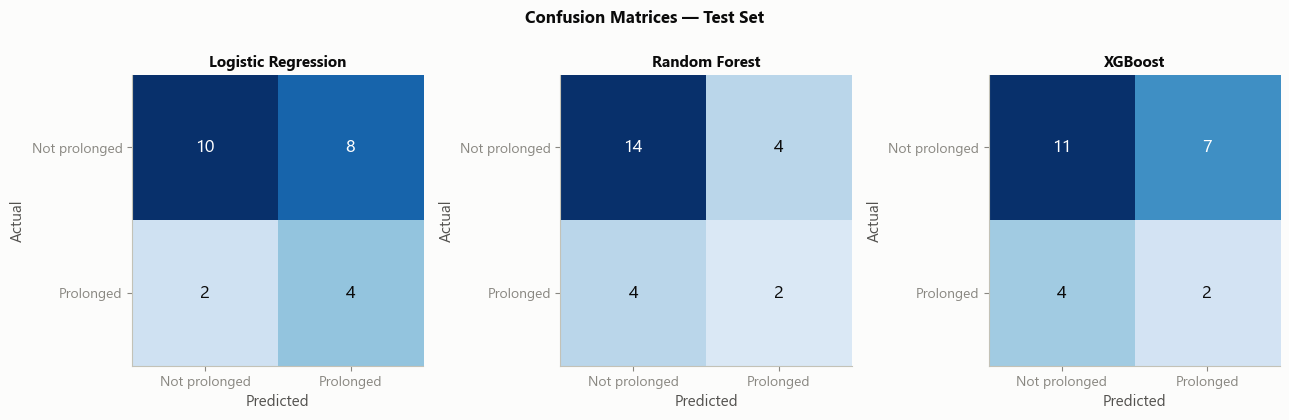

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res["pred"])
    im = ax.imshow(cm, cmap="Blues", vmin=0)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=13, color=INK_PRIMARY if cm[i, j] < cm.max()*0.6 else "white")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Not prolonged", "Prolonged"])
    ax.set_yticklabels(["Not prolonged", "Prolonged"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name, fontsize=11)
    ax.grid(False)
fig.suptitle("Confusion Matrices — Test Set", fontweight="bold")
save_fig(fig, "model_confusion_matrices")

## Part 5 — Model Comparison

In [10]:
comparison = pd.DataFrame({
    name: {
        "Test ROC-AUC": res["test_roc_auc"],
        "Test Precision": res["test_precision"],
        "Test Recall": res["test_recall"],
        "Test F1": res["test_f1"],
        "CV ROC-AUC Mean": res["cv_roc_auc_mean"],
        "CV ROC-AUC Std": res["cv_roc_auc_std"],
        "CV F1 Mean": res["cv_f1_mean"],
        "CV F1 Std": res["cv_f1_std"],
    }
    for name, res in test_results.items()
}).T.round(3)

comparison = comparison.sort_values("CV ROC-AUC Mean", ascending=False)
print(comparison.to_string())

comparison.to_csv(MODEL_DIR / "model_comparison.csv")
print(f"\nSaved: models/model_comparison.csv")

BEST_MODEL_NAME = comparison.index[0]
print(f"\nBest model (by 5-fold CV ROC-AUC mean, the more stable estimate at this sample size): {BEST_MODEL_NAME}")

                     Test ROC-AUC  Test Precision  Test Recall  Test F1  CV ROC-AUC Mean  CV ROC-AUC Std  CV F1 Mean  CV F1 Std
Random Forest               0.593           0.333        0.333    0.333            0.537           0.083       0.337      0.137
XGBoost                     0.481           0.222        0.333    0.267            0.533           0.082       0.272      0.076
Logistic Regression         0.593           0.333        0.667    0.444            0.441           0.141       0.326      0.180

Saved: models/model_comparison.csv

Best model (by 5-fold CV ROC-AUC mean, the more stable estimate at this sample size): Random Forest


**Best-performing model and why.** Ranked by 5-fold CV ROC-AUC mean — the
more stable estimate at this sample size, since it is averaged over 5
validation folds rather than a single 24-row test split — **Random Forest**
ranks first (≈0.537 ± 0.083), narrowly ahead of **XGBoost** (≈0.533 ± 0.082)
and clearly ahead of **Logistic Regression** (≈0.441 ± 0.141, *below* the
0.500 no-skill line on average across folds).

Two things temper any claim of a decisive winner:

1. **Random Forest's margin over XGBoost is within noise.** A CV-mean gap of
   ≈0.004 with comparable standard deviations is not a meaningful
   difference at 93 training rows — both tree ensembles are, practically
   speaking, tied.
2. **The single held-out test split tells a different story**: Logistic
   Regression and Random Forest *tie* for the best test ROC-AUC (both
   ≈0.593), while XGBoost scores lowest there (≈0.481). This split between
   the CV ranking and the one-shot test ranking is itself the most important
   finding of this comparison — it demonstrates concretely why a single
   train/test split is an unreliable way to rank models at this sample
   size, and why the CV mean (not the test-set score) is used as the
   primary selection criterion.

**Why the tree ensembles likely edge out the linear model.** The EDA
(`reports/EDA_summary.md` §2) already found that no individual feature
correlates with the target beyond r≈0.21 in magnitude — weak linear signal
throughout. Random Forest and XGBoost can capture nonlinear thresholds and
feature interactions (e.g. an elevated creatinine possibly mattering more
in combination with a CKD diagnosis than either alone) that a linear
decision boundary cannot, which is consistent with Logistic Regression
being the weakest and least stable of the three here.

**Interpretability vs. predictive performance trade-off.** Logistic
Regression is fully transparent — each coefficient is a directly readable
log-odds effect — but was the weakest and most volatile performer in this
comparison. Random Forest and XGBoost are ensembles of hundreds of trees;
no single coefficient explains a prediction, and feature importance from
the ensemble alone does not explain *individual* predictions. This is
precisely the gap the next project stage is designed to close: **SHAP
values applied to the saved Random Forest model** will recover
per-prediction, per-feature attribution — the interpretability of a linear
model's coefficients, without giving up the tree ensemble's ability to
capture nonlinear structure.

**Absolute performance caveat.** All three models remain close to the
0.5 no-skill line on the test set (0.48-0.59 ROC-AUC). This is consistent
with, not contrary to, the EDA's own findings and the project's explicitly
stated priority (`proposal.docx` §13) of engineering rigor over
benchmark-chasing performance. No hyperparameter tuning was attempted to
chase a better number on a 24-row test set — that would optimize for noise,
not signal.

## Part 6 — Save Outputs

In [11]:
best_pipeline = fitted_pipelines[BEST_MODEL_NAME]

MODEL_PATH = MODEL_DIR / "best_model.joblib"
joblib.dump(best_pipeline, MODEL_PATH)
print(f"Saved best model ({BEST_MODEL_NAME}) pipeline -> {MODEL_PATH.relative_to(PROJECT_ROOT)}")

FEATURES_PATH = MODEL_DIR / "feature_names.json"
with open(FEATURES_PATH, "w") as f:
    json.dump({
        "feature_names": FEATURE_NAMES,
        "numeric_cols": NUMERIC_COLS,
        "target_col": "prolonged_stay_label",
        "key_col": "stay_id",
        "best_model_name": BEST_MODEL_NAME,
    }, f, indent=2)
print(f"Saved feature metadata -> {FEATURES_PATH.relative_to(PROJECT_ROOT)}")

# The preprocessing step (scaler for numeric columns, passthrough for the
# rest) is already embedded as the "pre" step inside best_pipeline, so
# loading best_model.joblib alone is sufficient to preprocess + predict on
# new rows shaped like model_ready.csv's feature columns -- no separate
# scaler artifact is needed.
print(f"\nPipeline steps saved inside best_model.joblib: {[s[0] for s in best_pipeline.steps]}")

print("\nFiles under models/:")
for p in sorted(MODEL_DIR.glob("*")):
    print(" -", p.name)

Saved best model (Random Forest) pipeline -> models\best_model.joblib
Saved feature metadata -> models\feature_names.json

Pipeline steps saved inside best_model.joblib: ['pre', 'clf']

Files under models/:
 - best_model.joblib
 - feature_names.json
 - model_comparison.csv


## Summary

A full written summary — dataset, feature engineering decisions, model
performance, cross-validation, best model, limitations, and the SHAP next
step — is saved separately as `reports/modeling_summary.md`.

In [12]:
n_figs_total = len(list(FIG_DIR.glob("model_*.png")))
print(f"Model-stage figures on disk: {n_figs_total}")
print(f"Figures saved by this notebook run: {len(N_FIGURES_SAVED)}")
print(f"Best model: {BEST_MODEL_NAME}")
print(f"Models directory contents: {[p.name for p in sorted(MODEL_DIR.glob('*'))]}")
print()
print("Modeling completed successfully.")

Model-stage figures on disk: 3
Figures saved by this notebook run: 3
Best model: Random Forest
Models directory contents: ['best_model.joblib', 'feature_names.json', 'model_comparison.csv']

Modeling completed successfully.
